### Preamble

In [1364]:
from sympy import *
from dataclasses import dataclass

In [1365]:
# global tolerance
tol = 1e-4

# Algebraic Motion Planning

Instead of relying on numerical optimization (direct transcription), we can also rely on algebraic methods to solve the motion planning problem. This involves "smoothing" out the constraints enforced by the vehicle driving in front of the ego vehicle, by "glueing together" a finite number of polynomial trajectory segments. This results in a couple of quadratic equations that can be solved symbolically, for which we use the `sympy` library.

Although the results seem to be plausible when compared to direct transcription, we have no clear strategy for proving the correctness of this approach, e.g., by invoking the Pontryagin Maximum Principle.

## Partial trajectories

### Setup four trajectory segments

We use `omega_d` and `omega_a` for deceleration and acceleration constraints, corresponding to $\omega$ and $\bar{\omega}$ in the text.

In [1366]:
p, v, a, b, tau, omega_d, omega_a = symbols('p, v, a, b, tau, omega_d, omega_a', positive=True)

In [1367]:
acc = p + v*(tau - a) + omega_a*(tau - a)**2/2
dec = p + v*(tau - a) - omega_d*(tau - a)**2/2
stop = p
full = p + tau - a

Partial trajectories are determined by their type, their parameters $p$ and $v$, and their time domain $[a, b]$.

In [1368]:
@dataclass
class PartialTrajectory:
    x_func: Expr
    p: float = 0
    v: float = 0
    a: float = 0
    b: float = 1
    omega_d: float = 0.5
    omega_a: float = 0.5

    def __post_init__(self):
        assert self.a <= self.b
        assert 0 <= self.v <= 1
        # differentiate to get the velocity
        self.v_func = simplify(diff(self.x_func, tau))
        # update the substitution dict
        self.repl = { p:self.p, v:self.v, a:self.a, b:self.b, omega_d:self.omega_d, omega_a:self.omega_a }
        # verify that speed constraint is still satisfied at end of domain
        assert self.v_func.subs(self.repl, simultaneous=True).subs(tau, self.b) <= 1 + tol

    def update(self):
        # update the substitution dict
        self.repl = { p:self.p, v:self.v, a:self.a, b:self.b, omega_d:self.omega_d, omega_a:self.omega_a }
    
    @property
    def concrete_x(self):
        self.update()
        return self.x_func.subs(self.repl)

    @property
    def concrete_v(self):
        self.update()
        return self.v_func.subs(self.repl)

    def plot(self, **kwargs):
        return plot(self.concrete_x, (tau, self.a, self.b), **kwargs);
    
    def copy(self):
        return PartialTrajectory(x_func=self.x_func, p=self.p, v=self.v, a=self.a, b=self.b, omega_d=self.omega_d, omega_a=self.omega_a)

### Plot trajectories

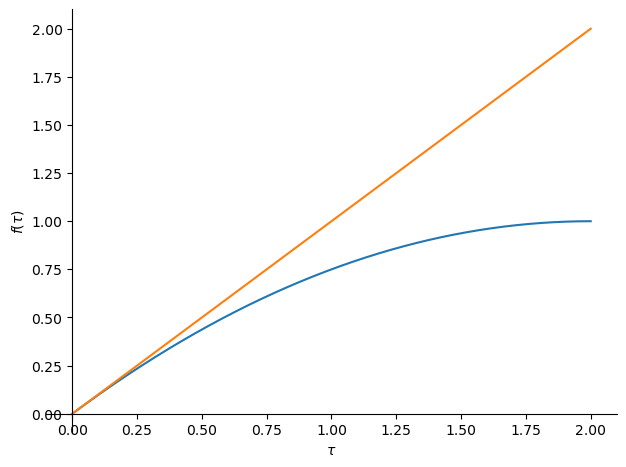

In [1369]:
plt = PartialTrajectory(dec, 0, 1, 0, 2).plot(show=False)
pl2 = PartialTrajectory(full, 0, 1, 0, 2).plot(show=False)
plt.extend(pl2)
plt.show()

## Connecting two partial trajectories

### Symbolic solving

In [1370]:
tau1, tau2 = symbols('tau_1, tau_2', positive=True)
p1, v1, a1, b1, p2, v2, a2, b2 = symbols('p_1, v_1, a_1, b_1, p_2, v_2, a_2, b_2', positive=True)
omega_a1, omega_d1, omega_a2, omega_d2 = symbols('omega_a1, omega_d1, omega_a2, omega_d2', positive=True)
omega_d3 = symbols('omega_d3', positive=True) # for connecting trajectory

In [1371]:
def connect(source: PartialTrajectory, target: PartialTrajectory, omega_d_connect=0.5) -> PartialTrajectory:
    # rename or variables to split into two groups
    tr1 = source.x_func.subs([(p, p1), (v, v1), (a, a1), (b, b1)])
    tr2 = target.x_func.subs([(p, p2), (v, v2), (a, a2), (b, b2)])
    # only split the symbols when concrete values are actually distinct,
    # otherwise we get an ill-posed system of equations
    if source.omega_a != target.omega_a:
        tr1 = tr1.subs(omega_a, omega_a1); tr2 = tr2.subs(omega_a, omega_a2)
    if source.omega_d != target.omega_d:
        tr1 = tr1.subs(omega_d, omega_d1); tr2 = tr2.subs(omega_d, omega_d2)
    
    # parameterize the connecting deceleration partial trajectory
    connect = dec.subs([
        (p, tr1.subs(tau, tau1)),
        (v, diff(tr1, tau).subs(tau, tau1)),
        (a, tau1),
        (b, tau2),
        (tau, tau2),
        # (omega_d, omega_d3)
    ], simultaneous=True)

    # again, for omega_d for connecting deceleration, we need to be careful:
    # only split the symbols when concrete values are actually distinct,
    # otherwise we get an ill-posed system of equations
    if omega_d_connect == source.omega_d and source.omega_d != target.omega_d:
        connect = connect.subs(omega_d, omega_d1)
    if omega_d_connect == target.omega_d and source.omega_d != target.omega_d:
        connect = connect.subs(omega_d, omega_d2)
    if omega_d_connect != source.omega_d and omega_d_connect != target.omega_d:
        connect = connect.subs(omega_d, omega_d3)

    # construct the two equations:
    #   connecting deceleration should touch target trajectory tangentially
    # with variables:
    #   tau1 = time of leaving source trajectory
    #   tau2 = time of touching target trajectory
    tr2 = tr2.subs(tau, tau2) 
    F = [ connect - tr2, diff(connect, tau2) - diff(tr2, tau2) ]

    # these are quadratic equations, so check both solutions for feasibility
    for t1, t2 in solve(F, tau1, tau2):
        # rename back... 
        back1 = [(p1, p), (v1, v), (a1, a), (b1, b), (omega_a1, omega_a), (omega_d1, omega_d)]
        back2 = [(p2, p), (v2, v), (a2, a), (b2, b), (omega_a2, omega_a), (omega_d2, omega_d)]
        # ...and substitute concrete parameters
        t1 = t1.subs(back1).subs(source.repl).subs(back2).subs(target.repl).subs(omega_d3, omega_d_connect)
        t2 = t2.subs(back1).subs(source.repl).subs(back2).subs(target.repl).subs(omega_d3, omega_d_connect)

        # check if tau1 in domain of source and tau2 in domain of target
        if source.a <= t1 <= source.b and target.a <= t2 <= target.b:
            # get the concrete parameters for the connecting deceleration
            p0 = source.x_func.subs(source.repl).subs(tau, t1)
            v0 = diff(source.x_func, tau).subs(source.repl).subs(tau, t1)
            return PartialTrajectory(dec, p0, v0, t1, t2, omega_d=omega_d_connect)
    
    # no feasible solution
    return None

### Demo

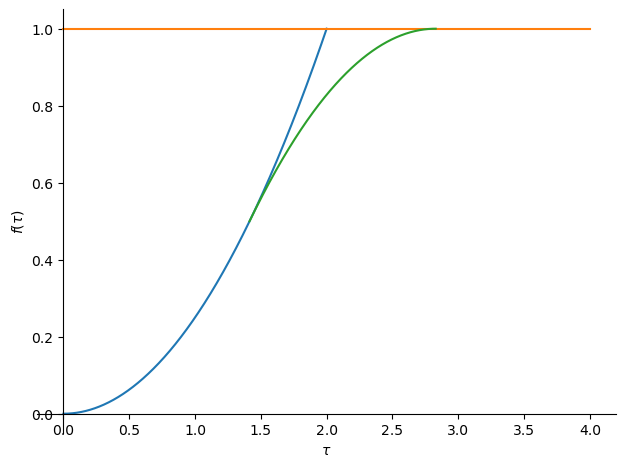

In [1372]:
tr1 = PartialTrajectory(acc, p=0, a=0, b=2, omega_a=0.5)
tr2 = PartialTrajectory(stop, p=1, a=0, b=4)
plt = tr1.plot(show=False)
pl2 = tr2.plot(show=False)
plt.extend(pl2)

tr3 = connect(tr1, tr2, omega_d_connect=0.5)
pl3 = tr3.plot(show=False)
plt.extend(pl3)

plt.show()

## Smoothing for alternating trajectories

### Trajectory class

A trajectory is defined as a sequence of partial trajectories.

We add a method to `trim` the trajectory partials such that they are properly connected.
While doing so, we also identify the points of discontinuity.
For each of these points, we try to connect one of the preceding partials with one of the succeeding partials, with respect to the current time. This is done in the `smooth` procedure.

In [1373]:
def intersection(tr1: PartialTrajectory, tr2: PartialTrajectory) -> float:
    for c in solve(tr1.concrete_x - tr2.concrete_x, tau):
        # check if intersection is in domain
        if c and tr1.a - tol <= c <= tr1.b + tol and tr2.a - tol <= c <= tr2.b + tol:
            return c

class Trajectory:
    def __init__(self, partials):
        self.partials = partials
    
    def plot(self, **kwargs):
        kwargs = {'show': False, 'line_color': 'k', **kwargs}
        pl = self.partials[0].plot(**kwargs)
        for partial in self.partials[1:]:
            pl.extend(partial.plot(**kwargs))
        return pl

    def remove(self, to_remove):
        # remove them in reversed order, otherwise indices get messed up
        for k in reversed(sorted(to_remove)):
            del self.partials[k]

    def trim(self):
        self.discontinuities = []
        i = 0
        while True:
            tr1 = self.partials[i]

            # keep track of succeeding partials with which there is no intersection,
            # until we find the first intersection
            to_remove = []
            for j in range(i + 1, len(self.partials)):
                tr2 = self.partials[j]

                # use stored link, if present
                if hasattr(tr1, 'link') and tr1.link == tr2:
                    break

                # check for intersection
                c = intersection(tr1, tr2)
                if not c:
                    # tag this partial for removal, because it is redundant
                    to_remove.append(j)
                    continue

                # trim the domains
                tr1.b = c
                # when changing `a`, we also need to update `p` and `v` accordingly
                p_new = tr2.concrete_x.subs(tau, c)
                v_new = tr2.concrete_v.subs(tau, c)
                tr2.p = p_new; tr2.v = v_new; tr2.a = c
                
                # check continuity TODO: add tolerance
                sp1 = diff(tr1.x_func, tau).subs(tr1.repl).subs(tau, tr1.b)
                sp2 = diff(tr2.x_func, tau).subs(tr2.repl).subs(tau, tr2.a)
                if sp1 != sp2:
                    self.discontinuities.append((tr1, tr2))
                
                # found an intersection
                break
        
            # remove redundant partials
            self.remove(to_remove)

            # NOTE:debug show intermediate trimming
            # self.plot().show()

            i += 1
            if i >= len(self.partials): return

    def smooth(self, omega_d_connect):
        for tr1, tr2 in self.discontinuities:
            i0 = self.partials.index(tr1)
            j0 = self.partials.index(tr2) # = i0+1
            # feasibility searching ("searching left and right", somewhat like a grid search)
            # NOTE: this may be more efficient if we travel "diagonally" through the grid
            before_range = reversed(range(0, i0 + 1))
            after_range = range(j0, len(self.partials))
            found = False
            for i in before_range:
                for j in after_range:
                    connecting_dec = connect(self.partials[i], self.partials[j], omega_d_connect)
                    if connecting_dec: found = True; break # ...from inner loop
                if connecting_dec: break # ...from outer loop
            
            if not found:
                raise Exception('no smoothing possible')

            # trim domains
            self.partials[i].b = connecting_dec.a
            # when changing `a`, we also need to update `p` and `v` accordingly
            tr2 = self.partials[j]
            p_new = tr2.concrete_x.subs(tau, connecting_dec.b)
            v_new = tr2.concrete_v.subs(tau, connecting_dec.b)
            tr2.p = p_new; tr2.v = v_new; tr2.a = connecting_dec.b

            # remove partials in between
            self.remove(range(i + 1, j))

            # insert connecting deceleration
            self.partials.insert(i + 1, connecting_dec)
    
    def downshift(self, shift):
        # shift existing partials down
        for partial in self.partials:
            partial.p = partial.p - shift
        
        # add full speed extension at the end
        last = self.partials[-1]
        p_end = last.concrete_x.subs(tau, last.b)
        self.partials.append(PartialTrajectory(full, p=p_end, a=last.b, b=last.b + shift))

### Demo

Construct the boundary of the first vehicle, which enters an empty system.

In [1441]:
# entry and cross locations
A = 0
B = 5

# acc/dec capabilities of current vehicle
omega_a_current = 0.6
omega_d_current = 1.0
acc_dist = 1/(2*omega_a_current)
acc_time = 1/omega_a_current

def next(entry_time, cross_time, u=None, plot=False):
    # full speed boundary
    x1 = PartialTrajectory(full, p=A, a=entry_time, b=entry_time + (B - A))
    # upper boundary: stop part
    x_hat1 = PartialTrajectory(stop, p=B - acc_dist, a=entry_time, b=cross_time - acc_time)
    # upper boundary: acc part
    x_hat2 = PartialTrajectory(acc, p=B - acc_dist, v=0, a=cross_time - acc_time, b=cross_time, omega_a=omega_a_current)
    if u is None: 
        tr = Trajectory([x1, x_hat1, x_hat2])
    else:
        partials = [partial.copy() for partial in u.partials]
        # link the partials of the lead boundary
        for i in range(len(partials) - 1):
            partials[i].link = partials[i+1]
        tr = Trajectory([x1, *partials, x_hat1, x_hat2])

    if plot: tr.plot().show()
    tr.trim()
    if plot: tr.plot().show()
    tr.smooth(omega_d_current)
    return tr

In [1458]:
def demo(schedule, L=1, size=(5,3)):
    entry, cross = schedule[0]
    tr = next(entry, cross)
    plt = tr.plot(size=size)
    tr.downshift(L)

    for entry, cross in schedule[1:]:
        tr = next(entry, cross, tr)
        plt.extend(tr.plot())
        tr.downshift(L)

    plt.show()

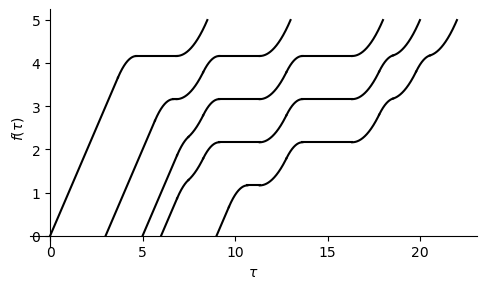

In [1459]:
demo([(0, 8.5), (3, 13), (5, 18), (6+tol, 20), (9, 22)])

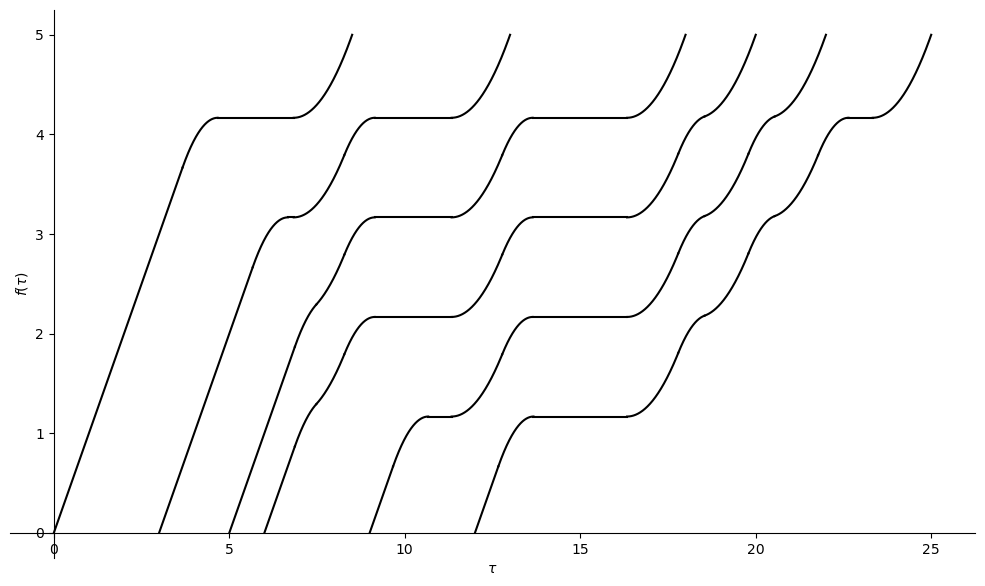

In [1463]:
demo([(0, 8.5), (3, 13), (5, 18), (6+tol, 20), (9, 22), (12, 25)], size=(10,6))